# Fake-News Style Classifier — Preprocessing & Evaluation

**Project:** ModernBERT binary style classifier (0 = FAKE_STYLE, 1 = REAL_STYLE)

This notebook documents the **actual preprocessing pipeline** implemented under `src/` and summarizes **model evaluation** on the held-out test set, with emphasis on **short vs. long texts**.

| Module | Role |
|--------|------|
| `src/text_cleaning.py` | Remove URLs, HTML, Reuters markers, boilerplate |
| `src/data_loader.py` | Load CSVs, clean title+body, normalize labels, deduplicate |
| `src/preprocess.py` | Tokenize with ModernBERT (`max_length=1024` training) |
| `evaluatemodel.py` | Evaluate checkpoint with same cleaning as training |

> **Note:** The classifier predicts *writing style*, not factual truth. Short headlines/snippets are inherently harder because the model was trained mostly on full articles.

In [2]:
from __future__ import annotations

import json
import re
import sys
from pathlib import Path

from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_repo_root() -> Path:
    for start in [Path.cwd(), *Path.cwd().parents]:
        if (start / "src" / "data_loader.py").exists():
            return start
    raise RuntimeError("Could not find repo root. Open Jupyter from the fakemodel folder.")

ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data_loader import clean_news_text, normalize_label, prepare_example

DATASETS = ROOT / "datasets"
EVAL_FULL = ROOT / "evaluationresults"
EVAL_GT30 = ROOT / "evaluation_resultsgt30"

COLORS = ["#4c78a8", "#f58518", "#54a24b", "#e45756", "#b279a2", "#ff9da6"]
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 120, "font.size": 11})
plt.style.use("ggplot")

print(f"Repo root: {ROOT}")

c:\Users\yosef\fakemodel\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Repo root: c:\Users\yosef\fakemodel


## 1. Text cleaning (`src/text_cleaning.py`)

Cleaning is intentionally **light** for Transformer models. We preserve natural wording and only remove artifacts that could cause **data leakage** or noise:

- HTML entities and tags
- URLs (`http://`, `www.`)
- Reuters-style datelines (`LONDON (Reuters) - ...`)
- Leading labels (`VIDEO:`, `BREAKING:`, …)
- Website boilerplate (`read more`, `subscribe now`, …)
- Whitespace normalization

We **do not** remove stop words, punctuation, or lowercase the article.

In [5]:
def show_cleaning_example(raw: str, title: str = "") -> None:
    before = f"{title}\n\n{raw}".strip() if title else raw
    after = prepare_example({"title": title, "text": raw, "label": 1}, apply_cleaning=True)["text"]
    print("=" * 80)
    print("BEFORE (first 400 chars)")
    print(before[:400] + ("..." if len(before) > 400 else ""))
    print("\nAFTER (first 400 chars)")
    print(after[:400] + ("..." if len(after) > 400 else ""))
    print(f"\nWords: {len(before.split())} -> {len(after.split())}")


# Real example from backup/test.csv (Reuters prefix + long body)
sample = pd.read_csv(DATASETS / "backup" / "test.csv", nrows=1).iloc[0]
show_cleaning_example(sample["text"])

BEFORE (first 400 chars)
UK parliament says government must publish secret Brexit impact studies LONDON (Reuters) - British lawmakers ramped up pressure on the government to publish its assessment of the impact Brexit will have on the economy, passing a motion in parliament on Wednesday which could compel the government to release the papers. The government said on Monday it had carried out 58 economic assessments, coveri...

AFTER (first 400 chars)
British lawmakers ramped up pressure on the government to publish its assessment of the impact Brexit will have on the economy, passing a motion in parliament on Wednesday which could compel the government to release the papers. The government said on Monday it had carried out 58 economic assessments, covering sectors from aerospace to tourism, but has so far refused requests from lawmakers to pub...

Words: 463 -> 450


,step,text,chars
0,Original,LONDON (Reuters) - Breaking news about markets...,152
1,HTML entities removed,LONDON (Reuters) - Breaking news about markets...,152
2,HTML tags removed,LONDON (Reuters) - Breaking news about markets...,147
3,URLs removed,LONDON (Reuters) - Breaking news about markets...,108
4,Reuters markers removed,LONDON - Breaking news about markets. Read m...,144
5,Full pipeline (clean_news_text),Breaking news about markets. at and to our new...,54


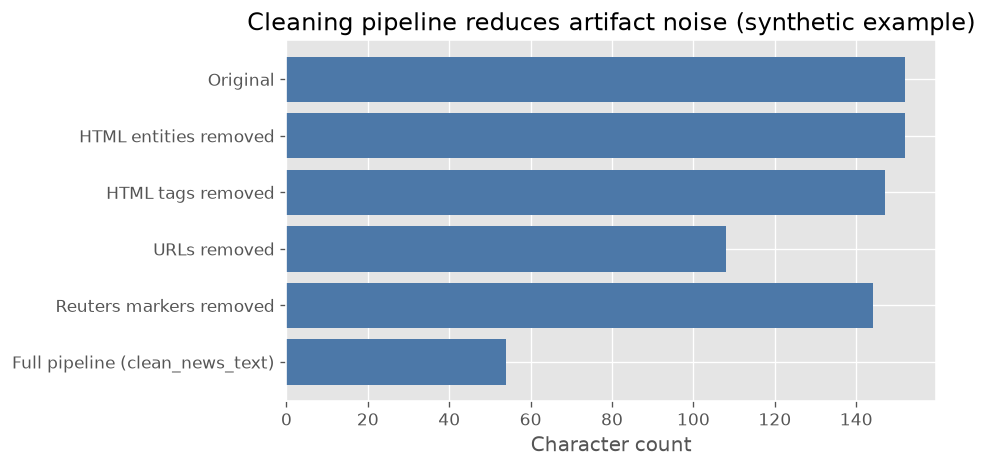

In [6]:
CLEANING_STEPS = [
    ("Original", lambda t: str(t)),
    ("HTML entities removed", lambda t: str(t).replace("&nbsp;", " ").replace("&amp;", "&")),
    ("HTML tags removed", lambda t: re.sub(r"<[^>]+>", " ", str(t))),
    ("URLs removed", lambda t: re.sub(r"https?://[^\s]+|www\.[^\s]+", " ", str(t), flags=re.I)),
    ("Reuters markers removed", lambda t: re.sub(r"\bReuters\b|\(\s*Reuters\s*\)", " ", str(t), flags=re.I)),
    ("Full pipeline (clean_news_text)", clean_news_text),
]

demo_text = (
    "LONDON (Reuters) - Breaking news about markets. "
    "Read more at https://example.com/article and www.news.com/story. "
    "<b>Subscribe now</b> to our newsletter."
)

step_rows = []
for name, fn in CLEANING_STEPS:
    out = fn(demo_text)
    out = re.sub(r"\s+", " ", out).strip() if name.startswith("Full") else out
    step_rows.append({"step": name, "text": out, "chars": len(out)})

steps_df = pd.DataFrame(step_rows)
display(steps_df[["step", "text", "chars"]])

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(steps_df["step"], steps_df["chars"], color=COLORS[0])
ax.set_xlabel("Character count")
ax.set_title("Cleaning pipeline reduces artifact noise (synthetic example)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 2. Dataset preparation (`src/data_loader.py`)

For each CSV row:

1. **Normalize column names** (lowercase, strip spaces)
2. **Clean title and body separately**, then combine: `title + "\n\n" + body`
3. **Normalize labels** → `0` fake, `1` real
4. **Filter** empty text or invalid labels
5. **Deduplicate** exact texts across train/validation/test (train kept first)

Training data (`datasets/train.csv`) is dominated by **long articles**; only ~3% of training rows have ≤30 words after cleaning.

In [8]:
def word_counts_for_csv(path: Path, nrows: int | None = None) -> pd.Series:
    df = pd.read_csv(path, nrows=nrows)
    cleaned = df["text"].map(clean_news_text)
    return cleaned.str.split().str.len()


paths = {
    "train": DATASETS / "train.csv",
    "valid": DATASETS / "valid.csv",
    "test": DATASETS / "test.csv",
}

summary_rows = []
wc_frames = []
for name, path in paths.items():
    wc = word_counts_for_csv(path)
    wc_frames.append(pd.DataFrame({"split": name, "word_count": wc}))
    summary_rows.append(
        {
            "split": name,
            "rows": len(wc),
            "median_words": wc.median(),
            "pct_le_30_words": (wc <= 30).mean() * 100,
            "pct_gt_300_words": (wc > 300).mean() * 100,
        }
    )

summary_df = pd.DataFrame(summary_rows)
display(summary_df.round({"median_words": 1, "pct_le_30_words": 2, "pct_gt_300_words": 2}))

wc_all = pd.concat(wc_frames, ignore_index=True)

,split,rows,median_words,pct_le_30_words,pct_gt_300_words
0,train,31280,366.0,2.94,63.47
1,valid,3910,358.0,2.53,62.33
2,test,3910,362.0,2.97,62.99


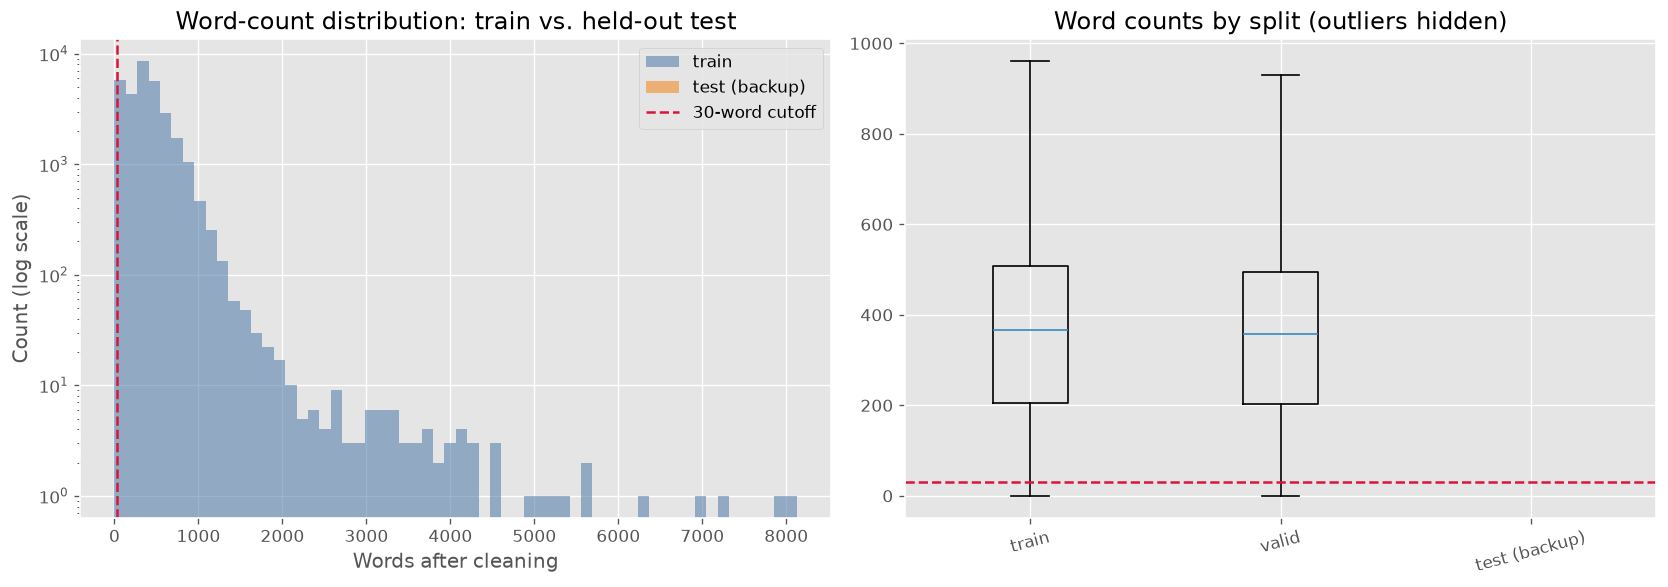

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram (log scale) — train vs backup test
for split, color in zip(["train", "test (backup)"], COLORS[:2]):
    subset = wc_all.loc[wc_all["split"] == split, "word_count"]
    axes[0].hist(subset, bins=60, alpha=0.55, label=split, color=color, log=True)
axes[0].axvline(30, color="crimson", linestyle="--", linewidth=1.5, label="30-word cutoff")
axes[0].set_xlabel("Words after cleaning")
axes[0].set_ylabel("Count (log scale)")
axes[0].set_title("Word-count distribution: train vs. held-out test")
axes[0].legend()

# Boxplot by split (matplotlib — set tick labels manually for version compatibility)
order = ["train", "valid", "test (backup)"]
box_data = [wc_all.loc[wc_all["split"] == s, "word_count"].values for s in order]
axes[1].boxplot(box_data, showfliers=False)
axes[1].set_xticks(range(1, len(order) + 1))
axes[1].set_xticklabels(order)
axes[1].axhline(30, color="crimson", linestyle="--", linewidth=1.5)
axes[1].set_title("Word counts by split (outliers hidden)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

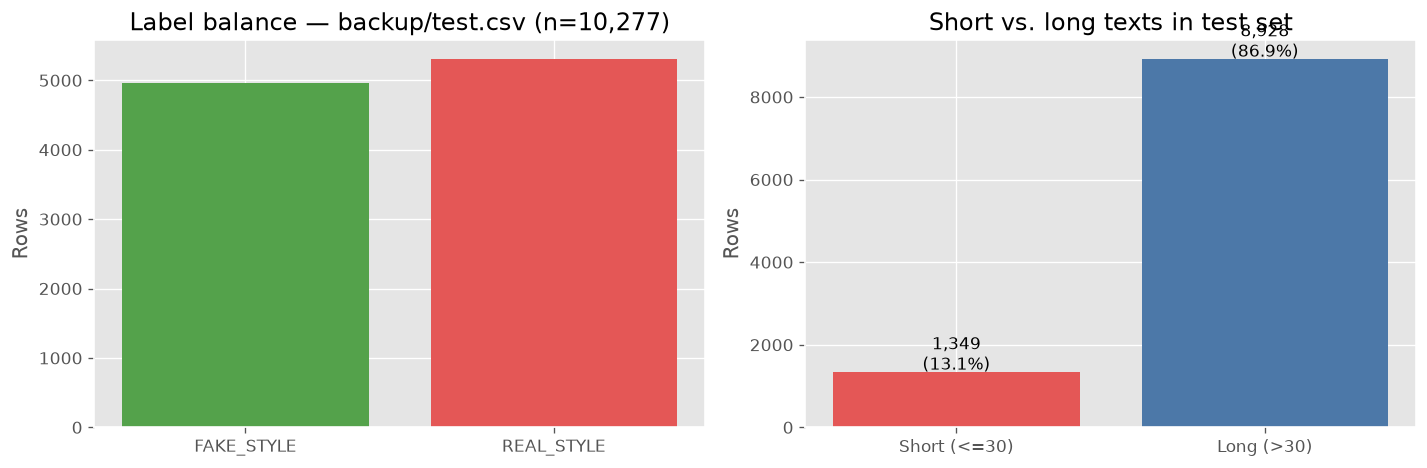

In [11]:
# Label balance on backup test set
test_df = pd.read_csv(DATASETS / "backup" / "test.csv", usecols=["text", "label"])
test_df["label_name"] = test_df["label"].map({0: "FAKE_STYLE", 1: "REAL_STYLE"})
test_df["word_count"] = test_df["text"].map(clean_news_text).str.split().str.len()
test_df["length_group"] = np.where(test_df["word_count"] <= 30, "Short (<=30)", "Long (>30)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

label_counts = test_df["label_name"].value_counts().reindex(["FAKE_STYLE", "REAL_STYLE"])
axes[0].bar(label_counts.index, label_counts.values, color=COLORS[2:4])
axes[0].set_title(f"Label balance — backup/test.csv (n={len(test_df):,})")
axes[0].set_ylabel("Rows")

length_counts = test_df["length_group"].value_counts().reindex(["Short (<=30)", "Long (>30)"])
axes[1].bar(length_counts.index, length_counts.values, color=["#e45756", "#4c78a8"])
axes[1].set_title("Short vs. long texts in test set")
axes[1].set_ylabel("Rows")
for i, v in enumerate(length_counts.values):
    axes[1].text(i, v + 50, f"{v:,}\n({v/len(test_df)*100:.1f}%)", ha="center")

plt.tight_layout()
plt.show()

## 3. Tokenization (`src/preprocess.py`)

After cleaning, text is tokenized with **`answerdotai/ModernBERT-large`**:

- Training: `max_length=1024`, truncation + padding to max length
- Evaluation: `max_length=512` (see `evaluatemodel.py`)

The cell below shows how truncation affects very long articles at inference time.

In [12]:
try:
    from src.preprocess import TransformerPreprocessor

    preprocessor = TransformerPreprocessor(max_length=512)
    long_example = test_df.sort_values("word_count", ascending=False).iloc[0]
    cleaned_long = clean_news_text(long_example["text"])
    tokens = preprocessor.tokenizer(cleaned_long, truncation=True, max_length=512)
    token_count = len(tokens["input_ids"])

    print(f"Longest test article: {long_example['word_count']} words")
    print(f"Tokens after truncation (max_length=512): {token_count}")
    print(f"Approx. truncation ratio: {min(1.0, 512 / (long_example['word_count'] * 1.3)):.0%} of content kept")
except Exception as exc:
    print(f"Tokenizer demo skipped ({exc}). Run from repo root with venv + transformers installed.")

c:\Users\yosef\fakemodel\venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\yosef\.cache\huggingface\hub\models--answerdotai--ModernBERT-large. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Longest test article: 16399 words
Tokens after truncation (max_length=512): 512
Approx. truncation ratio: 2% of content kept


## 4. Model evaluation

Evaluation uses the **same training cleaner** (`cleaning_mode=training`) via `packages.ml.clean_news_text` → `src/text_cleaning.py`.

| Run | Test CSV | Rows | Overall accuracy |
|-----|----------|------|------------------|
| Full test | `datasets/backup/test.csv` | 10,277 | **90.9%** |
| >30 words only | `datasets/backup/test_gt30_words.csv` | 8,932 | **95.9%** |

Results loaded from saved runs in `evaluationresults/` and `evaluation_resultsgt30/` (produced by `make evaluate-backup` and `make evaluate-backup-gt30`).

In [13]:
def load_eval_bundle(folder: Path) -> dict:
    metrics_path = folder / "metrics.json"
    length_path = folder / "accuracy_by_length.csv"
    if not metrics_path.exists():
        raise FileNotFoundError(f"Missing {metrics_path}. Run: make evaluate-backup")
    with metrics_path.open(encoding="utf-8") as f:
        metrics = json.load(f)
    length_df = pd.read_csv(length_path)
    return {"metrics": metrics, "length_df": length_df, "folder": folder}


full_eval = load_eval_bundle(EVAL_FULL)
gt30_eval = load_eval_bundle(EVAL_GT30)

compare = pd.DataFrame(
    [
        {
            "dataset": "Full backup test",
            "rows": full_eval["metrics"]["number_of_examples"],
            "accuracy": full_eval["metrics"]["accuracy"],
            "macro_f1": full_eval["metrics"]["macro_f1"],
            "fake_f1": full_eval["metrics"]["per_class"]["FAKE_STYLE"]["f1"],
            "real_f1": full_eval["metrics"]["per_class"]["REAL_STYLE"]["f1"],
        },
        {
            "dataset": "Test >30 words",
            "rows": gt30_eval["metrics"]["number_of_examples"],
            "accuracy": gt30_eval["metrics"]["accuracy"],
            "macro_f1": gt30_eval["metrics"]["macro_f1"],
            "fake_f1": gt30_eval["metrics"]["per_class"]["FAKE_STYLE"]["f1"],
            "real_f1": gt30_eval["metrics"]["per_class"]["REAL_STYLE"]["f1"],
        },
    ]
)
display(compare.assign(
    accuracy=lambda d: (d["accuracy"] * 100).round(2),
    macro_f1=lambda d: (d["macro_f1"] * 100).round(2),
    fake_f1=lambda d: (d["fake_f1"] * 100).round(2),
    real_f1=lambda d: (d["real_f1"] * 100).round(2),
))

,dataset,rows,accuracy,macro_f1,fake_f1,real_f1
0,Full backup test,10277,90.93,90.92,90.68,91.17
1,Test >30 words,8932,95.92,95.92,95.83,96.02


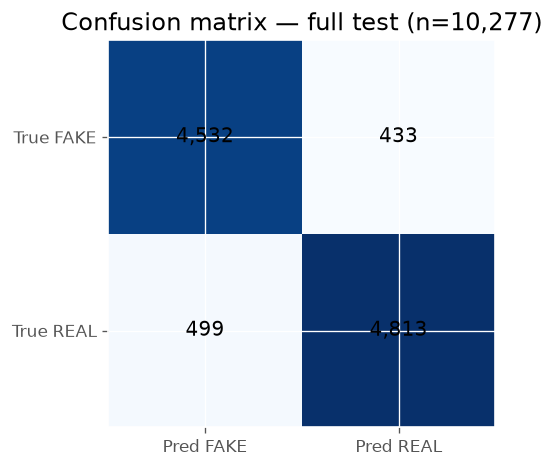

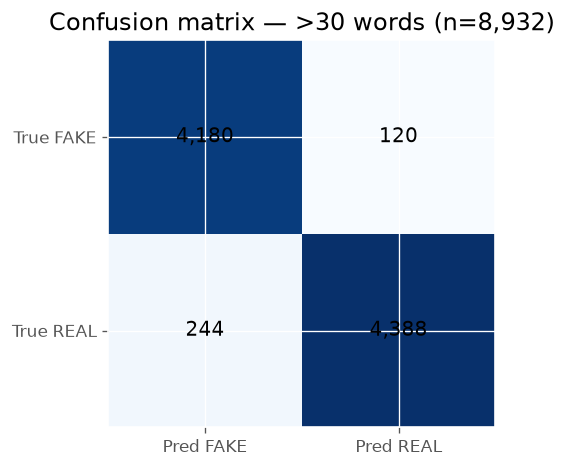

In [14]:
def plot_confusion(cm: list[list[int]], title: str) -> None:
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1], labels=["Pred FAKE", "Pred REAL"])
    ax.set_yticks([0, 1], labels=["True FAKE", "True REAL"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i][j]:,}", ha="center", va="center", color="black", fontsize=12)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


plot_confusion(full_eval["metrics"]["confusion_matrix"], "Confusion matrix — full test (n=10,277)")
plot_confusion(gt30_eval["metrics"]["confusion_matrix"], "Confusion matrix — >30 words (n=8,932)")

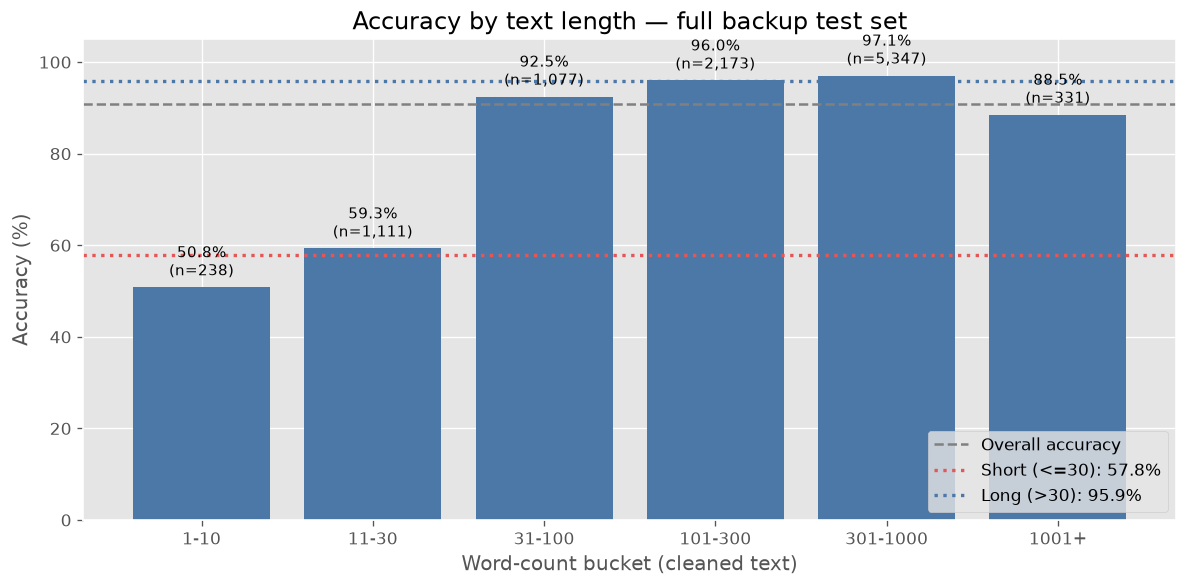

Short texts (<=30 words): 57.8% accuracy on 1,349 examples
Long texts  (>30 words):  95.9% accuracy on 8,928 examples


In [15]:
length_full = full_eval["length_df"].copy()
length_full["accuracy_pct"] = length_full["accuracy"] * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(length_full["length_bucket"], length_full["accuracy_pct"], color=COLORS[0])
ax.axhline(full_eval["metrics"]["accuracy"] * 100, color="gray", linestyle="--", label="Overall accuracy")
ax.set_ylabel("Accuracy (%)")
ax.set_xlabel("Word-count bucket (cleaned text)")
ax.set_ylim(0, 105)
ax.set_title("Accuracy by text length — full backup test set")

for bar, row in zip(bars, length_full.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{row.accuracy_pct:.1f}%\n(n={row.samples:,})",
        ha="center",
        va="bottom",
        fontsize=9,
    )

short_mask = length_full["length_bucket"].isin(["1-10", "11-30"])
short_acc = length_full.loc[short_mask, "correct"].sum() / length_full.loc[short_mask, "samples"].sum()
long_acc = length_full.loc[~short_mask, "correct"].sum() / length_full.loc[~short_mask, "samples"].sum()
ax.axhline(short_acc * 100, color="#e45756", linestyle=":", linewidth=2, label=f"Short (<=30): {short_acc*100:.1f}%")
ax.axhline(long_acc * 100, color="#4c78a8", linestyle=":", linewidth=2, label=f"Long (>30): {long_acc*100:.1f}%")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Short texts (<=30 words): {short_acc*100:.1f}% accuracy on {length_full.loc[short_mask, 'samples'].sum():,} examples")
print(f"Long texts  (>30 words):  {long_acc*100:.1f}% accuracy on {length_full.loc[~short_mask, 'samples'].sum():,} examples")

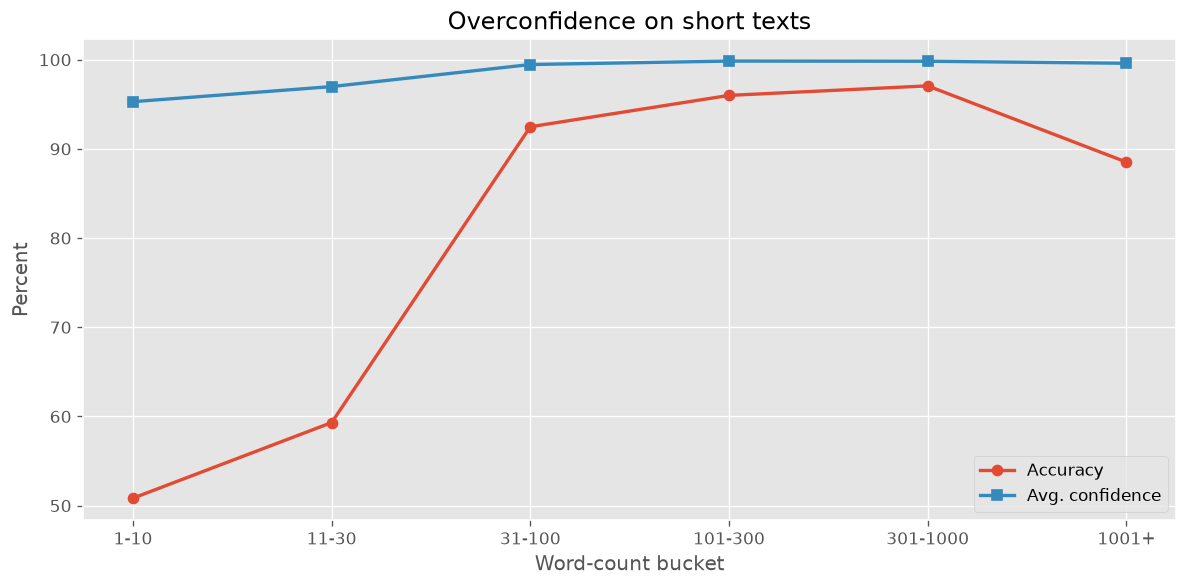

In [16]:
# Confidence vs. accuracy — model is overconfident on short texts
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(length_full["length_bucket"], length_full["accuracy_pct"], marker="o", linewidth=2, label="Accuracy")
ax.plot(
    length_full["length_bucket"],
    length_full["average_confidence"] * 100,
    marker="s",
    linewidth=2,
    label="Avg. confidence",
)
ax.set_ylabel("Percent")
ax.set_xlabel("Word-count bucket")
ax.set_title("Overconfidence on short texts")
ax.legend()
plt.tight_layout()
plt.show()

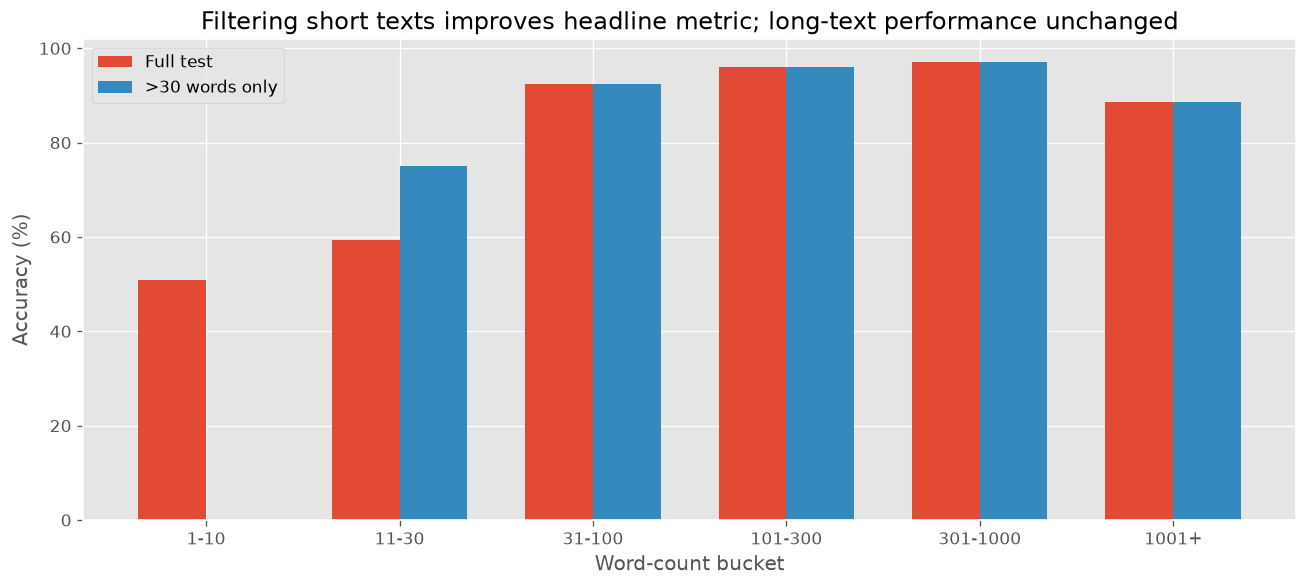

,length_bucket,samples_full,accuracy_full,samples_gt30,accuracy_gt30
0,1-10,238,50.8,0,NaN
1,11-30,1111,59.3,4,75.0
2,31-100,1077,92.5,1077,92.5
3,101-300,2173,96.0,2173,96.0
4,301-1000,5347,97.1,5347,97.1
5,1001+,331,88.5,331,88.5


In [17]:
# Side-by-side: full test vs. filtered >30 words (same buckets >=31 words are identical)
merged = length_full.merge(
    gt30_eval["length_df"],
    on="length_bucket",
    suffixes=("_full", "_gt30"),
    how="left",
)

x = np.arange(len(merged))
width = 0.35
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width / 2, merged["accuracy_full"] * 100, width, label="Full test")
ax.bar(x + width / 2, merged["accuracy_gt30"] * 100, width, label=">30 words only")
ax.set_xticks(x)
ax.set_xticklabels(merged["length_bucket"])
ax.set_ylabel("Accuracy (%)")
ax.set_xlabel("Word-count bucket")
ax.set_title("Filtering short texts improves headline metric; long-text performance unchanged")
ax.legend()
plt.tight_layout()
plt.show()

display(
    merged[
        [
            "length_bucket",
            "samples_full",
            "accuracy_full",
            "samples_gt30",
            "accuracy_gt30",
        ]
    ].assign(
        accuracy_full=lambda d: (d["accuracy_full"] * 100).round(1),
        accuracy_gt30=lambda d: (d["accuracy_gt30"] * 100).round(1),
    )
)

## 5. Key findings (summary for supervisor)

### Preprocessing
- Implemented in `src/text_cleaning.py` and orchestrated by `src/data_loader.py`.
- Removes leakage artifacts (URLs, HTML, Reuters tags, boilerplate) while keeping article wording intact.
- Title and body are cleaned separately, then concatenated — matching training and evaluation.
- Cross-split deduplication prevents the same article from appearing in train and test.

### Data distribution
- **Training set:** ~31k rows, median ~366 words, only **~3%** ≤30 words.
- **Test set (backup):** includes **~13%** short texts (≤30 words) — a distribution shift vs. training.

### Model performance
- **Overall (full test):** 90.9% accuracy, macro-F1 0.909.
- **Short texts (≤30 words):** ~51–59% accuracy per bucket, despite >95% model confidence → **overconfident on snippets**.
- **Long texts (>30 words):** ~93–97% accuracy — aligns with training distribution.
- Removing ≤30-word rows (`test_gt30_words.csv`) raises accuracy to **95.9%** without changing long-text bucket scores.

### Implications
- The model is reliable on **full-article** inputs but should not be trusted alone on **headlines/tweets**.
- For production: warn users on short inputs, or retrain with more short-text augmentation.

---
*To regenerate evaluation artifacts:*
```bash
make evaluate-backup          # full test -> evaluationresults/
make evaluate-backup-gt30     # >30 words -> evaluation_resultsgt30/
make filter-backup-gt30       # rebuild test_gt30_words.csv
```